     E-LIBRARY DATA INSIGHTS DASHBOARD
     Beginner Level Project

=== Loading Data ===
CSV file loaded successfully
Total rows before cleaning: 65
All required columns are present
Data cleaning done
Total valid rows now: 61

=== Calculating Statistics ===
Most Borrowed Book: Atomic Habits
Times borrowed    : 8
Average Borrowing Duration : 15.33 days
Standard Deviation         : 4.84 days
Minimum Duration           : 7 days
Maximum Duration           : 28 days
Busiest Day of Week        : Monday

          E-LIBRARY DATA INSIGHTS REPORT
Total Transactions : 61
Unique Users       : 16
Unique Books       : 12

Top 5 Most Borrowed Books:
   1 . Atomic Habits - 8 times
   2 . The Silent Patient - 7 times
   3 . The Alchemist - 6 times
   4 . Sapiens - 6 times
   5 . The Midnight Library - 6 times

Books Borrowed by Genre:
   Fiction : 12
   History : 6
   Memoir : 9
   Psychology : 4
   Science Fiction : 8
   Self-Help : 11
   Thriller : 11

Example: Filtering Thriller books only
=== Filt

C:\Users\Admin\AppData\Local\Temp\ipykernel_16668\3387170452.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.values, y=top5.index, palette="coolwarm")


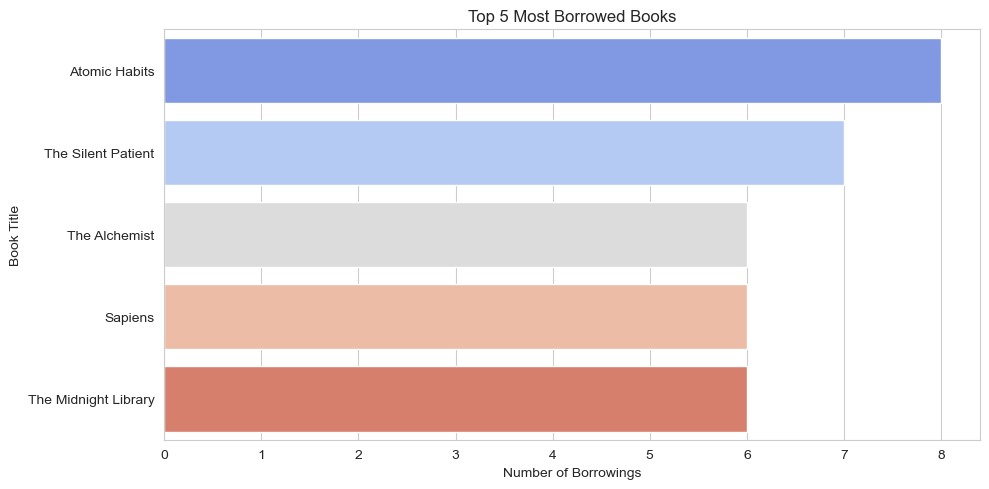

Showing Line Graph: Borrowing Trends Over Months


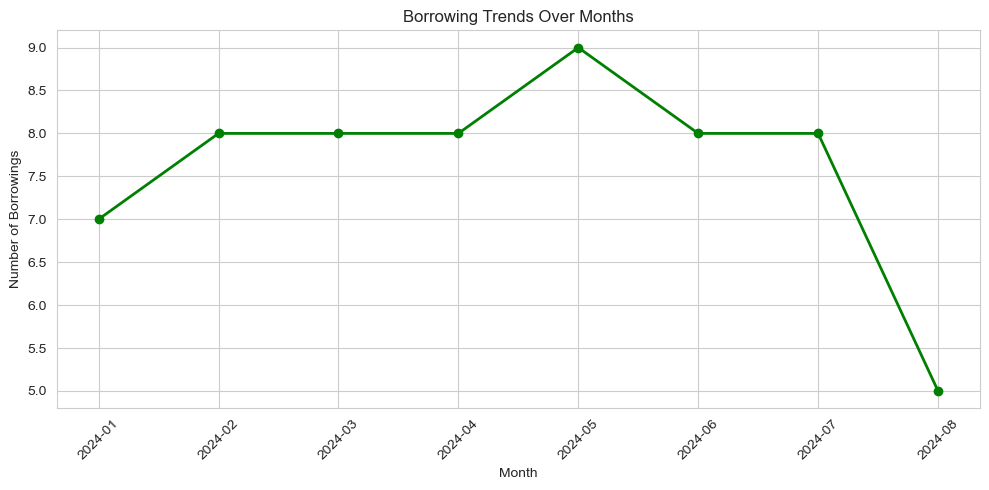

Showing Pie Chart: Distribution by Genre


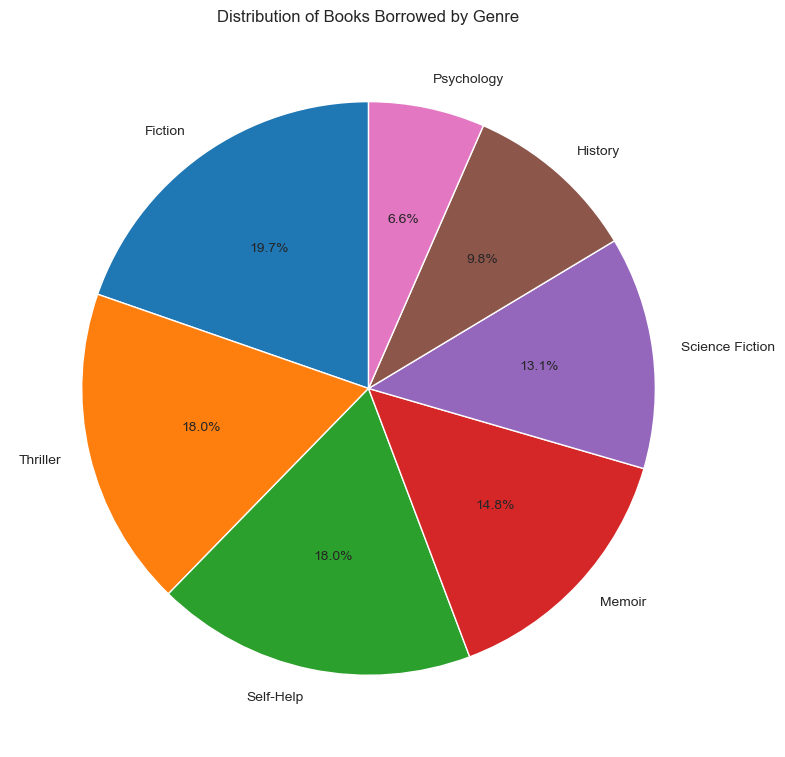

Showing Heatmap: Borrowing Activity by Day


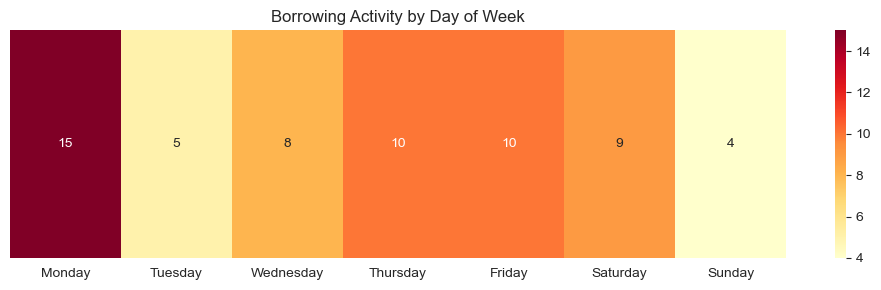

Program completed successfully!
Thank you!


In [3]:
# ============================================================
# Project Title: E-Library Data Insights Dashboard
# Red & White Skill Education - Practical Exam Set B
# Simple beginner level code
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


class LibraryDashboard:
    # This is the main class for our dashboard

    def _init_(self):
        self.df = None   # we will store data here

    # --------------------------------------------------------
    # 1. load_data method  (Data Input and Validation)
    # Uses control structures and checks for missing data
    # --------------------------------------------------------
    def load_data(self, file_path):
        print("=== Loading Data ===")

        # Check if file is csv or not (control structure)
        if not file_path.endswith(".csv"):
            print("Error: File must be a CSV file")
            return False

        # Try to read the file
        try:
            self.df = pd.read_csv(file_path)
            print("CSV file loaded successfully")
            print("Total rows before cleaning:", len(self.df))
        except:
            print("Error: Cannot read the file")
            return False

        # Check all required columns are present (using loop)
        required_cols = ["Transaction ID", "Date", "User ID", 
                         "Book Title", "Genre", "Borrowing Duration (Days)"]

        for col in required_cols:
            if col not in self.df.columns:
                print("Error: Missing column -", col)
                return False

        print("All required columns are present")

        # ---------- Data Cleaning using control structures ----------

        # Convert Borrowing Duration to number
        self.df["Borrowing Duration (Days)"] = pd.to_numeric(
            self.df["Borrowing Duration (Days)"], errors="coerce"
        )

        # Remove rows where important columns are missing
        self.df = self.df.dropna(subset=["Transaction ID", "Date", "User ID", "Book Title"])

        # Remove rows where duration is missing or less than or equal to 0
        self.df = self.df[self.df["Borrowing Duration (Days)"] > 0]

        # Convert Date to proper date format
        self.df["Date"] = pd.to_datetime(self.df["Date"], errors="coerce")
        self.df = self.df.dropna(subset=["Date"])

        # If Genre is missing, put "Unknown"
        self.df["Genre"] = self.df["Genre"].fillna("Unknown")

        # Remove duplicate Transaction ID
        self.df = self.df.drop_duplicates(subset=["Transaction ID"])

        # Reset the index
        self.df = self.df.reset_index(drop=True)

        # Create new columns for analysis
        self.df["Month"] = self.df["Date"].dt.strftime("%Y-%m")
        self.df["DayOfWeek"] = self.df["Date"].dt.day_name()

        print("Data cleaning done")
        print("Total valid rows now:", len(self.df))
        print()
        return True

    # --------------------------------------------------------
    # 2. calculate_statistics method
    # Uses NumPy for average and standard deviation
    # --------------------------------------------------------
    def calculate_statistics(self):
        print("=== Calculating Statistics ===")

        # Most borrowed book
        book_counts = self.df["Book Title"].value_counts()
        most_borrowed_book = book_counts.index[0]
        most_borrowed_count = book_counts.iloc[0]

        print("Most Borrowed Book:", most_borrowed_book)
        print("Times borrowed    :", most_borrowed_count)

        # Use NumPy array for duration calculations
        duration_array = self.df["Borrowing Duration (Days)"].to_numpy()

        average = np.mean(duration_array)
        std_dev = np.std(duration_array)
        minimum = np.min(duration_array)
        maximum = np.max(duration_array)

        print("Average Borrowing Duration :", round(average, 2), "days")
        print("Standard Deviation         :", round(std_dev, 2), "days")
        print("Minimum Duration           :", int(minimum), "days")
        print("Maximum Duration           :", int(maximum), "days")

        # Busiest day
        day_counts = self.df["DayOfWeek"].value_counts()
        busiest_day = day_counts.index[0]
        print("Busiest Day of Week        :", busiest_day)
        print()

    # --------------------------------------------------------
    # 3. filter_transactions method
    # --------------------------------------------------------
    def filter_transactions(self, condition):
        print("=== Filtering Transactions ===")

        filtered = self.df.copy()

        if "genre" in condition:
            filtered = filtered[filtered["Genre"].str.lower() == condition["genre"].lower()]

        if "start_date" in condition:
            start = pd.to_datetime(condition["start_date"])
            filtered = filtered[filtered["Date"] >= start]

        if "end_date" in condition:
            end = pd.to_datetime(condition["end_date"])
            filtered = filtered[filtered["Date"] <= end]

        if "min_duration" in condition:
            filtered = filtered[filtered["Borrowing Duration (Days)"] >= condition["min_duration"]]

        print("Number of records after filter:", len(filtered))
        print()
        return filtered

    # --------------------------------------------------------
    # 4. generate_report method
    # --------------------------------------------------------
    def generate_report(self):
        print("=" * 55)
        print("          E-LIBRARY DATA INSIGHTS REPORT")
        print("=" * 55)

        print("Total Transactions :", len(self.df))
        print("Unique Users       :", self.df["User ID"].nunique())
        print("Unique Books       :", self.df["Book Title"].nunique())
        print()

        print("Top 5 Most Borrowed Books:")
        top5 = self.df["Book Title"].value_counts().head(5)
        number = 1
        for book, count in top5.items():
            print("  ", number, ".", book, "-", count, "times")
            number = number + 1
        print()

        print("Books Borrowed by Genre:")
        genre_group = self.df.groupby("Genre").size()
        for genre, count in genre_group.items():
            print("  ", genre, ":", count)
        print("=" * 55)
        print()

    # --------------------------------------------------------
    # 5. Visualizations
    # --------------------------------------------------------
    def plot_top5_books(self):
        print("Showing Bar Chart: Top 5 Most Borrowed Books")
        top5 = self.df["Book Title"].value_counts().head(5)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=top5.values, y=top5.index, palette="coolwarm")
        plt.title("Top 5 Most Borrowed Books")
        plt.xlabel("Number of Borrowings")
        plt.ylabel("Book Title")
        plt.tight_layout()
        plt.show()

    def plot_monthly_trends(self):
        print("Showing Line Graph: Borrowing Trends Over Months")
        monthly = self.df.groupby("Month").size()

        plt.figure(figsize=(10, 5))
        plt.plot(monthly.index, monthly.values, marker="o", color="green", linewidth=2)
        plt.title("Borrowing Trends Over Months")
        plt.xlabel("Month")
        plt.ylabel("Number of Borrowings")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_genre_pie(self):
        print("Showing Pie Chart: Distribution by Genre")
        genre_counts = self.df["Genre"].value_counts()

        plt.figure(figsize=(8, 8))
        plt.pie(genre_counts, labels=genre_counts.index, autopct="%1.1f%%", startangle=90)
        plt.title("Distribution of Books Borrowed by Genre")
        plt.tight_layout()
        plt.show()

    def plot_heatmap(self):
        print("Showing Heatmap: Borrowing Activity by Day")
        day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", 
                     "Friday", "Saturday", "Sunday"]
        day_counts = self.df["DayOfWeek"].value_counts().reindex(day_order, fill_value=0)

        heat_data = pd.DataFrame([day_counts.values], columns=day_order)

        plt.figure(figsize=(10, 3))
        sns.heatmap(heat_data, annot=True, fmt="d", cmap="YlOrRd")
        plt.title("Borrowing Activity by Day of Week")
        plt.yticks([])
        plt.tight_layout()
        plt.show()


# ============================================================
# MAIN PROGRAM
# ============================================================
def main():
    print("=" * 55)
    print("     E-LIBRARY DATA INSIGHTS DASHBOARD")
    print("     Beginner Level Project")
    print("=" * 55)
    print()

    # Create object of LibraryDashboard class
    dashboard = LibraryDashboard()

    # Step 1: Load and validate data
    file_name = "library_transactions.csv"
    success = dashboard.load_data(file_name)

    if success == False:
        print("Cannot continue without data. Program ending.")
        return

    # Step 2: Calculate statistics
    dashboard.calculate_statistics()

    # Step 3: Generate report
    dashboard.generate_report()

    # Step 4: Filter example
    print("Example: Filtering Thriller books only")
    filtered = dashboard.filter_transactions({"genre": "Thriller"})
    print(filtered[["Transaction ID", "Book Title", "Genre", "Borrowing Duration (Days)"]].head())
    print()

    # Step 5: Show all graphs
    print("=== Now Showing All Graphs ===")
    print()

    dashboard.plot_top5_books()       # Bar Chart
    dashboard.plot_monthly_trends()   # Line Graph
    dashboard.plot_genre_pie()        # Pie Chart
    dashboard.plot_heatmap()          # Heatmap

    print("Program completed successfully!")
    print("Thank you!")


if __name__ == "__main__":
    main()